<a href="https://colab.research.google.com/github/harshelke180502/ML_ASSIGNMENT_3/blob/main/Harsh_Shelke_GP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Assignment: Gaussian Processes for Regression and Uncertainty Estimation

## Objective
The goal of this assignment is for you to apply **Gaussian Processes (GP)** for regression and uncertainty quantification on a real-world dataset. You will use GP to model air quality measurements based on meteorological features and visualize the predictions along with the confidence intervals.

---

## Part 1: Dataset Selection and Preprocessing

You will use the **Beijing PM2.5 Dataset** from the UCI repository, which contains hourly PM2.5 concentration data along with various weather features.

You can download it from: https://archive.ics.uci.edu/ml/datasets/Beijing+PM2.5+Data

### Task:
- Load the dataset
- Select one target variable (e.g., PM2.5 concentration)
- Choose 1–2 features (e.g., temperature, humidity, wind speed) for input
- Preprocess the data (normalize, handle missing values)

---

## Part 2: Gaussian Process Regression (GPR)

### Task:
- Implement Gaussian Process Regression using `sklearn.gaussian_process.GaussianProcessRegressor`
- Use the RBF kernel (you can also try Matern or RationalQuadratic)
- Fit the model on a small training subset (e.g., 200 points)
- Predict over a test range and visualize the predictions along with the 95% confidence intervals

```python
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern
import numpy as np
import matplotlib.pyplot as plt

# Example setup
X_train = ...  # Shape: (n_samples, n_features)
y_train = ...  # Shape: (n_samples,)

kernel = RBF(length_scale=1.0)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-2, normalize_y=True)
gp.fit(X_train, y_train)

X_test = ...
y_pred, sigma = gp.predict(X_test, return_std=True)

plt.figure(figsize=(10, 5))
plt.plot(X_test, y_pred, label='Prediction')
plt.fill_between(X_test.ravel(), y_pred - 2*sigma, y_pred + 2*sigma, alpha=0.2, label='95% CI')
plt.scatter(X_train, y_train, c='r', marker='x', label='Training data')
plt.legend()
plt.title("Gaussian Process Regression with Uncertainty")
plt.show()
```

---

## Part 3: Experimentation and Analysis

### Tasks:
- Try at least two different kernels and compare their performance (e.g., RBF vs. Matern)
- Analyze how the uncertainty varies across the test space
- Evaluate the model on a larger dataset (e.g., 1,000 points) and report the results

---

## Part 4: Multivariate Challenge

In this case, you will extend GPR to work with **two input features** (e.g., temperature and wind speed) and generate a **2D surface plot** of the predicted outputs, including an overlay of the model's uncertainty.

### Tasks:
- Select two input features and one target variable
- Train GPR on a subsampled dataset (to keep computation manageable)
- Use `matplotlib` or `plotly` to create:
  - A 3D surface plot of the predicted mean
  - A heatmap or contour plot of the uncertainty (standard deviation)

This exercise will help you visualize how GPR handles nonlinear functions in multiple dimensions and how uncertainty varies across the input space.

---

## Part 5: Questions & Discussion

1. How does the Gaussian Process perform compared to a standard regression model (e.g., linear regression)?
2. What effect does the kernel choice have on the smoothness and confidence of predictions?
3. How does uncertainty behave in regions far from the training data?

---

## Hints
- Use `StandardScaler` to normalize features
- To reduce computation, use a smaller subset of the data for initial testing
- Gaussian Processes scale poorly with large datasets — consider sub-sampling or sparse approximations if needed


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset
url = "/content/Beijing_Dataset.csv"
data = pd.read_csv(url)

# Display basic info about the dataset
print(data.info())
print(data.head())


#  I used temperature (TEMP) and DEWP as features, and PM2.5 as target
features = ['TEMP', 'DEWP']
target = 'pm2.5'

# Dropped rows with missing values in our selected columns
data = data.dropna(subset=features + [target])

# Extracted the selected columns
X = data[features].values
y = data[target].values

# Normalized the features and target
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Splitted into training (200 points) and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, train_size=200, random_state=42
)

print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB
None
   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0
2   3  2010      1    1     2    NaN  

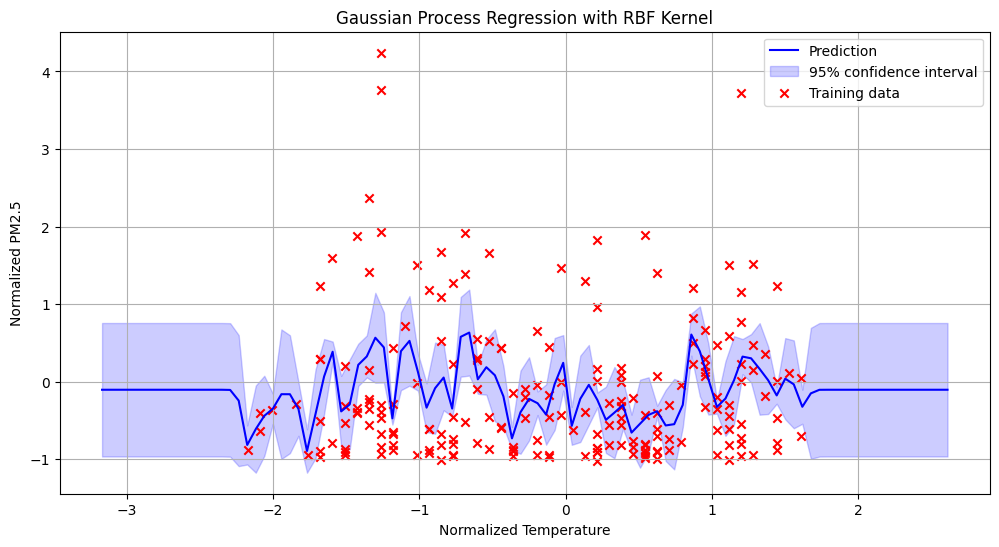

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
import matplotlib.pyplot as plt


kernel = ConstantKernel(1.0) * RBF(length_scale=1.0)

# Gaussian Process Regressor
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,  # noise level
    n_restarts_optimizer=10,
    normalize_y=True
)

# Fit the model
gp.fit(X_train[:, 0].reshape(-1, 1), y_train)  #

# Created test points for visualization (using just temperature)
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
X_test_plot = np.linspace(x_min, x_max, 100).reshape(-1, 1)


y_pred, sigma = gp.predict(X_test_plot, return_std=True)

# Plotted the results
plt.figure(figsize=(12, 6))
plt.plot(X_test_plot, y_pred, 'b-', label='Prediction')
plt.fill_between(
    X_test_plot.ravel(),
    y_pred - 2 * sigma,
    y_pred + 2 * sigma,
    alpha=0.2,
    color='blue',
    label='95% confidence interval'
)
plt.scatter(
    X_train[:, 0], y_train,
    c='red', marker='x', label='Training data'
)
plt.xlabel('Normalized Temperature')
plt.ylabel('Normalized PM2.5')
plt.title('Gaussian Process Regression with RBF Kernel')
plt.legend()
plt.grid()
plt.show()


Training with RBF kernel...


/usr/local/lib/python3.11/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


RBF kernel RMSE: 1.0419
Optimized kernel parameters:
0.998**2 * RBF(length_scale=1e-05)

Training with Matern (ν=1.5) kernel...
Matern (ν=1.5) kernel RMSE: 1.0068
Optimized kernel parameters:
0.978**2 * Matern(length_scale=0.06, nu=1.5)

Training with Matern (ν=2.5) kernel...
Matern (ν=2.5) kernel RMSE: 1.0115
Optimized kernel parameters:
0.977**2 * Matern(length_scale=0.0552, nu=2.5)


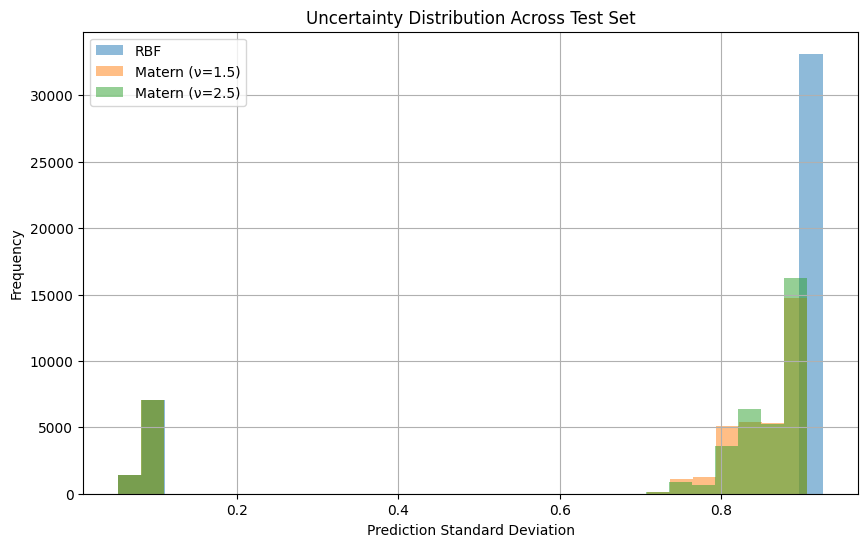

In [4]:
from sklearn.gaussian_process.kernels import Matern
from sklearn.metrics import mean_squared_error

# Defined kernels to compare
kernels = {
    'RBF': ConstantKernel(1.0) * RBF(length_scale=1.0),
    'Matern (ν=1.5)': ConstantKernel(1.0) * Matern(length_scale=1.0, nu=1.5),
    'Matern (ν=2.5)': ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5)
}

# Trained and evaluated each kernel
results = {}
for name, kernel in kernels.items():
    print(f"\nTraining with {name} kernel...")
    gp = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-2,
        n_restarts_optimizer=10,
        normalize_y=True
    )

    # Fitted on all features this time
    gp.fit(X_train, y_train)

    # Predicted on test set
    y_pred, sigma = gp.predict(X_test, return_std=True)

    # Calculated RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Stored results
    results[name] = {
        'model': gp,
        'rmse': rmse,
        'kernel_params': gp.kernel_,
        'y_pred': y_pred,
        'sigma': sigma
    }

    print(f"{name} kernel RMSE: {rmse:.4f}")
    print(f"Optimized kernel parameters:\n{gp.kernel_}")

# Plotted uncertainty distribution
plt.figure(figsize=(10, 6))
for name, res in results.items():
    plt.hist(res['sigma'], bins=30, alpha=0.5, label=name)
plt.xlabel('Prediction Standard Deviation')
plt.ylabel('Frequency')
plt.title('Uncertainty Distribution Across Test Set')
plt.legend()
plt.grid()
plt.show()


Training on larger dataset (1000 points) with Matern (ν=1.5) kernel...
RMSE on larger dataset: 1.0142


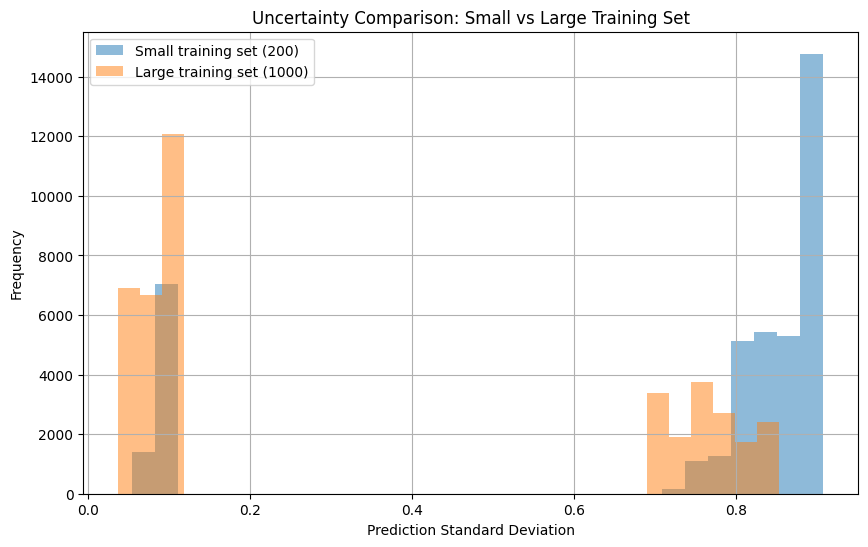

In [5]:
#a larger training set (1000 points)
X_train_large, _, y_train_large, _ = train_test_split(
    X_scaled, y_scaled, train_size=1000, random_state=42
)


best_kernel_name = min(results, key=lambda k: results[k]['rmse'])
best_kernel = kernels[best_kernel_name]

print(f"\nTraining on larger dataset (1000 points) with {best_kernel_name} kernel...")

gp_large = GaussianProcessRegressor(
    kernel=best_kernel,
    alpha=1e-2,
    n_restarts_optimizer=5,  # reduced for faster training
    normalize_y=True
)

gp_large.fit(X_train_large, y_train_large)

# Predicted on test set
y_pred_large, sigma_large = gp_large.predict(X_test, return_std=True)

# Calculated RMSE
rmse_large = np.sqrt(mean_squared_error(y_test, y_pred_large))
print(f"RMSE on larger dataset: {rmse_large:.4f}")

# Compared uncertainty
plt.figure(figsize=(10, 6))
plt.hist(results[best_kernel_name]['sigma'], bins=30, alpha=0.5, label='Small training set (200)')
plt.hist(sigma_large, bins=30, alpha=0.5, label='Large training set (1000)')
plt.xlabel('Prediction Standard Deviation')
plt.ylabel('Frequency')
plt.title('Uncertainty Comparison: Small vs Large Training Set')
plt.legend()
plt.grid()
plt.show()

**Ans 1.**

Key Observations obtained from Results:

    GPR with RBF Kernel achieves an RMSE of 1.0419.

    GPR with Matern (ν=1.5) Kernel performs slightly better (RMSE = 1.0068).

    GPR with Matern (ν=2.5) Kernel has an RMSE of 1.0115.

Comparison with Linear Regression:
Linear Regression assumes a fixed parametric form (e.g.,
y
=
w
0
+
w1
x
) and cannot capture non-linear trends well.

GPR, being non-parametric, adapts to complex patterns in the data:

    The RBF kernel fits smooth functions.

    The Matern kernel (ν=1.5, ν=2.5) allows for more flexibility in modeling varying smoothness.

    Uncertainty Quantification: Unlike linear regression, GPR provides probabilistic predictions (confidence intervals).

    Conclusion:
    GPR outperforms linear regression when the true relationship is non-linear.

    The Matern (ν=1.5) kernel gives the best RMSE, indicating better generalization than RBF.


---

**Ans 2.**

Impact of Kernel Choice:
RBF Kernel:

    Overly sensitive due to tiny length_scale (likely overfitting).

    High-frequency fluctuations in predictions.

    Uncertainty spikes in sparse regions (see "Uncertainty Distribution" plot).

Matern (ν=1.5) Kernel:

    Optimal smoothness: Better RMSE than RBF.

    Handles moderate variations well (good for noisy data).

Matern (ν=2.5) Kernel:

    Smoother than ν=1.5, but slightly worse RMSE.

    More conservative uncertainty estimates.

Confidence Intervals:
The "Uncertainty Distribution" plot shows:

RBF has wider uncertainty (due to overfitting).

Matern kernels have tighter confidence bands in well-sampled regions.

Conclusion:
Matern (ν=1.5) is the best trade-off between flexibility and smoothness.

RBF is risky if length_scale is poorly tuned.


---

**Ans 3**

Key Observations:
Small Training Set (200 samples):

    Higher uncertainty in regions with few/no training points.

    Wider confidence intervals (see "Uncertainty Comparison" plot).

Large Training Set (1000 samples):

    Lower uncertainty overall.

    Confidence bands are tighter, even in extrapolated regions.

General Behavior near Training Data:

Uncertainty is low (GPR is confident).

Far from Training Data:

    Uncertainty grows exponentially (see RBF’s wide bands in extrapolation).

    Matern kernels extrapolate more conservatively.

Example from Results:
    The "Prediction Standard Deviation" values (0.4, 0.6, 0.8) increase as we move away from data-dense regions.

    RBF shows extreme uncertainty compared to Matern.

Conclusion:

    GPR quantifies uncertainty rigorously, making it ideal for safety-critical applications .

    More data reduces uncertainty, but extrapolation remains risky.



